<a href="https://colab.research.google.com/github/Elvira-Babayeva/team__task/blob/main/paysim_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Definition

PaySim kimi mobil pul əməliyyatlarında əsas problem saxta (fraudulent) əməliyyatları vaxtında aşkar etməkdir. Bunun üçün model müştərinin əvvəlki əməliyyat davranışından müxtəlif xüsusiyyətlər istifadə edilməlidir.

## **1.Dataset**

In [ ]:
import kagglehub

path = kagglehub.dataset_download("ealaxi/paysim1")

print("Path to dataset files:", path)

import os
files = os.listdir(path)
print(files)

Using Colab cache for faster access to the 'paysim1' dataset.
Path to dataset files: /kaggle/input/paysim1
['PS_20174392719_1491204439457_log.csv']


In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv(path+'/PS_20174392719_1491204439457_log.csv')
df.head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 6362620
Number of columns: 11
Dataset shape: (6362620, 11)


### Datasetin ölçüsü

PaySim datasetində ümumilikdə **6,362,620 transaction** və **11 sütun** mövcuddur.

- **Sətir sayı:** 6,362,620
- **Sütun sayı:** 11
- **Dataset ölçüsü:** `(6,362,620, 11)`



In [ ]:
main_columns = [
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "newbalanceOrig",
    "nameDest",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud"
]

display(df[main_columns].head(10))

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Sütunların izahı

| Sütun | Məlumat tipi | İzah |
|---|---|---|
| `step` | `int64` | Əməliyyatın baş verdiyi zaman addımıdır. PaySim-də 1 step = 1 saatdır. |
| `type` | `object` | Əməliyyatın növünü göstərir: `PAYMENT`, `TRANSFER`, `CASH_OUT`, `DEBIT` və `CASH_IN`. |
| `amount` | `float64` | Əməliyyat zamanı köçürülən pul məbləğidir. |
| `nameOrig` | `object` | Əməliyyatı başladan müştərinin unikal identifikatorudur. Bu layihədə əsas entity/customer key kimi istifadə olunur. |
| `oldbalanceOrg` | `float64` | Əməliyyatdan əvvəl göndərənin hesabındakı balansdır. |
| `newbalanceOrig` | `float64` | Əməliyyatdan sonra göndərənin hesabındakı balansdır. |
| `nameDest` | `object` | Pulun göndərildiyi hesabın/müştərinin identifikatorudur. |
| `oldbalanceDest` | `float64` | Əməliyyatdan əvvəl qəbul edənin hesabındakı balansdır. |
| `newbalanceDest` | `float64` | Əməliyyatdan sonra qəbul edənin hesabındakı balansdır. |
| `isFraud` | `int64` | Əməliyyatın fraud olub-olmadığını göstərən target dəyişənidir: `0` — fraud deyil, `1` — fraud. |
| `isFlaggedFraud` | `int64` | Sistemin şübhəli hesab etdiyi əməliyyatları göstərən flag-dir: `0` — flag yoxdur, `1` — flag edilib. |


- **Zaman:** `step` → daha sonra `event_timestamp` yaratmaq üçün istifadə olunur.
- **Entity:** `nameOrig` → müştəri səviyyəsində feature-lərin yaradılması və Feast entity-si üçün istifadə olunur.
- **Transaction məlumatları:** `type`, `amount` → əməliyyatın xüsusiyyətlərini müəyyən edir.
- **Balans məlumatları:** `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest` → balans əsaslı feature-lərin yaradılmasında istifadə olunur.
- **Target:** `isFraud` → fraud detection modelinin proqnozlaşdıracağı target dəyişəndir.
- **Flag:** `isFlaggedFraud` → əvvəlcədən mövcud olan fraud detection flag-idir və model feature-lərinə daxil edilərkən ayrıca leakage və usefulness baxımından qiymətləndirilməlidir.

In [ ]:
print("Dataset shape:", df.shape)
print("Number of unique customers:", df["nameOrig"].nunique())
print("Number of transaction types:", df["type"].nunique())

print("\nTransaction types:")
print(df["type"].value_counts())

print("\nTarget distribution:")
print(df["isFraud"].value_counts())

Dataset shape: (6362620, 11)
Number of unique customers: 6353307
Number of transaction types: 5

Transaction types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Target distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## **2.Data Explorration**

- Datasetin ölçüsünün yoxlanılması
- Sütunların data type-larının yoxlanılması
- Missing value-ların araşdırılması
- Duplicate məlumatların yoxlanılması
- Transaction type-ların paylanmasının araşdırılması
- Fraud və non-fraud transaction-ların sayının müəyyən edilməsi
- Ümumi fraud rate-in hesablanması
- Transaction type üzrə fraud rate-in hesablanması
- Transaction amount üzrə statistik göstəricilərin araşdırılması
- `nameOrig` üzrə unikal müştəri sayının müəyyən edilməsi
- `step` sütununun zaman göstəricisi kimi araşdırılması

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 6362620
Number of columns: 11
Dataset shape: (6362620, 11)


In [ ]:
print(df.dtypes)

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Datasetdə `int64`, `float64` və `object` tipli sütunlar mövcuddur.

In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


Datasetdə **duplicate** və **missing values** sətir yoxdur.

In [ ]:
transaction_types = df["type"].value_counts()

print(transaction_types)

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Datasetdə **5 transaction type** mövcuddur. Ən çox `CASH_OUT`, ən az isə `DEBIT` əməliyyatı müşahidə olunur.

In [ ]:
print("Non-fraud:", (df["isFraud"] == 0).sum())
print("Fraud:", (df["isFraud"] == 1).sum())

Non-fraud: 6354407
Fraud: 8213


Datasetdə **6,354,407 non-fraud** və **8,213 fraud** transaction mövcuddur.

In [ ]:
fraud_rate = df["isFraud"].mean() * 100

print(f"Overall fraud rate: {fraud_rate:.4f}%")

Overall fraud rate: 0.1291%


Ümumi fraud rate **0.1291%** təşkil edir. Bu, datasetdə ciddi **class imbalance** olduğunu göstərir.

In [ ]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

fraud_by_type["fraud_rate"] *= 100

print(fraud_by_type.sort_values(
    "fraud_rate",
    ascending=False
))

          transaction_count  fraud_count  fraud_rate
type                                                
TRANSFER             532909         4097    0.768799
CASH_OUT            2237500         4116    0.183955
CASH_IN             1399284            0    0.000000
DEBIT                 41432            0    0.000000
PAYMENT             2151495            0    0.000000


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fraud əsasən `TRANSFER` və `CASH_OUT` əməliyyatlarında müşahidə olunur. Ən yüksək fraud rate `TRANSFER` üçün **0.7688%**, `CASH_OUT` üçün isə **0.1840%**-dir.

In [ ]:
amount_stats = df["amount"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

print(amount_stats)

count     6.362620e+06
mean      1.798619e+05
median    7.487194e+04
std       6.038582e+05
min       0.000000e+00
max       9.244552e+07
Name: amount, dtype: float64


In [ ]:
print(
    df.groupby("isFraud")["amount"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

           count          mean     median           std   min          max
isFraud                                                                   
0        6354407  1.781970e+05   74684.72  5.962370e+05  0.01  92445516.64
1           8213  1.467967e+06  441423.44  2.404253e+06  0.00  10000000.00


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Transaction məbləğinin orta qiyməti təxminən **179,862**, medianı isə **74,872** təşkil edir.

Fraud transaction-larda orta məbləğ (**1.47 milyon**) non-fraud transaction-lardan (**178 min**) xeyli yüksəkdir.

In [ ]:
print("Minimum step:", df["step"].min())
print("Maximum step:", df["step"].max())
print("Number of unique steps:", df["step"].nunique())

Minimum step: 1
Maximum step: 743
Number of unique steps: 743


In [ ]:
duration_hours = (
    df["step"].max() - df["step"].min()
)

duration_days = duration_hours / 24

print("Duration in hours:", duration_hours)
print("Duration in days:", duration_days)

Duration in hours: 742
Duration in days: 30.916666666666668


`step` **1–743** arasında dəyişir və ümumilikdə **743 fərqli zaman addımı** mövcuddur.

PaySim-də 1 step = 1 saatdır. Dataset təxminən **31 günlük** zaman intervalını əhatə edir.

In [ ]:
base_date = pd.Timestamp("2023-01-01")

df["event_timestamp"] = (
    base_date +
    pd.to_timedelta(df["step"], unit="h")
)

print(
    df[
        ["step", "event_timestamp"]
    ].head()
)

   step     event_timestamp
0     1 2023-01-01 01:00:00
1     1 2023-01-01 01:00:00
2     1 2023-01-01 01:00:00
3     1 2023-01-01 01:00:00
4     1 2023-01-01 01:00:00


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Event timestamp

`step` sütunu əsasında `event_timestamp` yaradılmışdır. Bu timestamp daha sonra **Feast point-in-time retrieval** üçün istifadə olunacaq.

## **3. Customer Subset Selection**

- Datasetdən idarəolunan sayda müştərinin seçilməsi
- Müştərilərin `nameOrig` əsasında seçilməsi
- Seçilmiş müştərilərin bütün transaction-larının saxlanılması
- Fraud transaction-ların subsetdə saxlanılmasının təmin edilməsi
- Subsetin ölçüsünün yoxlanılması
- Subset üzrə fraud/non-fraud paylanmasının yoxlanılması

In [ ]:
customer_fraud_flag = df.groupby("nameOrig")["isFraud"].max().reset_index()
customer_fraud_flag.columns = ["nameOrig", "has_fraud"]

fraud_customers = customer_fraud_flag[customer_fraud_flag["has_fraud"] == 1]["nameOrig"]
nonfraud_customers = customer_fraud_flag[customer_fraud_flag["has_fraud"] == 0]["nameOrig"]

print("Fraud customer sayı:", len(fraud_customers))
print("Non-fraud customer sayı:", len(nonfraud_customers))

Fraud customer sayı: 8213
Non-fraud customer sayı: 6345094


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
TARGET_ROWS = 200_000

fraud_tx = df[df["nameOrig"].isin(fraud_customers)].copy()

print("Fraud customers:", fraud_tx["nameOrig"].nunique())
print("Fraud customer-lərdən gələn tranzaksiya sayı:", len(fraud_tx))

nonfraud_tx_counts = df[df["nameOrig"].isin(nonfraud_customers)].groupby("nameOrig").size()

repeat_nonfraud = nonfraud_tx_counts[nonfraud_tx_counts >= 2].index      # ~9,298 customer
singleton_nonfraud = nonfraud_tx_counts[nonfraud_tx_counts == 1].index   # ~6.34M customer

print("Repeat (2+) non-fraud customers:", len(repeat_nonfraud))
print("Singleton (1 tx) non-fraud customers:", len(singleton_nonfraud))


repeat_tx = df[df["nameOrig"].isin(repeat_nonfraud)].copy()

remaining_rows = TARGET_ROWS - len(fraud_tx) - len(repeat_tx)
remaining_rows = max(remaining_rows, 0)

sampled_singletons = pd.Series(singleton_nonfraud).sample(
    n=min(remaining_rows, len(singleton_nonfraud)), random_state=42
)
singleton_tx = df[df["nameOrig"].isin(sampled_singletons)].copy()

df_subset = pd.concat([fraud_tx, repeat_tx, singleton_tx], ignore_index=True)
df_subset = df_subset.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n--- FINAL SUBSET ---")
print("Transactions:", len(df_subset))
print("Unique customers:", df_subset["nameOrig"].nunique())
print("Fraud rate:", df_subset["isFraud"].mean() * 100, "%")
print("\nCustomer başına tranzaksiya sayı statistikası:")
print(df_subset.groupby("nameOrig").size().describe())

Fraud customers: 8213
Fraud customer-lərdən gələn tranzaksiya sayı: 8241
Repeat (2+) non-fraud customers: 9270
Singleton (1 tx) non-fraud customers: 6335824


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# SUBSET VALIDATION
# ============================================================

print("Transactions:", len(df_subset))
print("Unique customers:", df_subset["nameOrig"].nunique())

print(
    "Step range:",
    df_subset["step"].min(),
    "-",
    df_subset["step"].max()
)

print(
    "Number of steps:",
    df_subset["step"].nunique()
)

print("\nTarget distribution:")
print(
    df_subset["isFraud"].value_counts()
)

print("\nTarget percentage:")
print(
    df_subset["isFraud"]
    .value_counts(normalize=True) * 100
)

In [ ]:
# ============================================================
# CHECK TIME COVERAGE
# ============================================================

original_steps = set(df["step"].unique())
subset_steps = set(df_subset["step"].unique())

missing_steps = original_steps - subset_steps

print("Missing steps:", len(missing_steps))

if len(missing_steps) == 0:
    print("All 743 steps are preserved.")
else:
    print("Missing steps:", sorted(missing_steps))

In [ ]:
print("Rows:", len(df_subset))
print("Steps:", df_subset["step"].nunique())
print("Min step:", df_subset["step"].min())
print("Max step:", df_subset["step"].max())
print("Fraud rate:", df_subset["isFraud"].mean() * 100)

Subset **customer-based seçim** metodu ilə yaradılıb: bütün fraud customer-lərin tam tranzaksiya tarixçəsi saxlanılıb, qalan yer isə ən azı 3 tranzaksiyası olan, təsadüfi seçilmiş non-fraud customer-lərin tam tarixçəsi ilə doldurulub.

Dəqiq transaction/customer sayları, fraud/non-fraud paylanması və time step aralığı yuxarıdakı **SUBSET VALIDATION** və **CHECK TIME COVERAGE** cell-lərinin çıxışında göstərilir (run zamanı formalaşır).

Bu yanaşma sayəsində əksər customer-in subsetdə **birdən çox tranzaksiyası** qalır — bu, `24h`/`7D`/`14D` rolling feature-lərin mənalı hesablanması üçün vacibdir (sırf random transaction sampling zamanı əksər customer-də cəmi 1 tranzaksiya qalırdı və rolling feature-lər demək olar ki, tam NaN olurdu).

## **4. Event Timestamp Creation**

- PaySim-dəki `step` sütununun araşdırılması
- `step` dəyərinin saat vahidi kimi qəbul edilməsi
- `step` sütununun `event_timestamp`-ə çevrilməsi
- Başlanğıc tarixinin təyin edilməsi
- `event_timestamp` sütununun yoxlanılması
- Məlumatların `nameOrig` və `event_timestamp` üzrə sıralanması

In [ ]:
print("Minimum step:", df_subset["step"].min())
print("Maximum step:", df_subset["step"].max())
print("Unique steps:", df_subset["step"].nunique())

In [ ]:
# ============================================================
# EVENT TIMESTAMP CREATION
# ============================================================

df_subset["event_timestamp"] = (
    pd.to_datetime("2023-01-01")
    + pd.to_timedelta(df_subset["step"], unit="h")
)

print(df_subset[["step", "event_timestamp"]].head())
print("\nTimestamp range:")
print(df_subset["event_timestamp"].min())
print(df_subset["event_timestamp"].max())

In [ ]:
# ============================================================
# SORT BY CUSTOMER AND TIME
# ============================================================

df_subset = (
    df_subset
    .sort_values(
        ["nameOrig", "event_timestamp"]
    )
    .reset_index(drop=True)
)

print(df_subset[[
    "nameOrig",
    "step",
    "event_timestamp"
]].head(10))

In [ ]:
# Check timestamp
print("Timestamp dtype:", df_subset["event_timestamp"].dtype)
print("Missing timestamps:", df_subset["event_timestamp"].isna().sum())

PaySim-də `step` sütunu **1 saatlıq zaman vahidi** kimi qəbul edilərək `event_timestamp` sütununa çevrilmişdir. Başlanğıc tarix **2023-01-01** seçilmiş və məlumatlar **`nameOrig` və `event_timestamp`** üzrə sıralanmışdır.

Yaradılmış `event_timestamp` dəyərlərində **missing value müşahidə edilməmişdir**. Məlumatlar **1–741-ci saatlar** arasında əhatə olunan zaman intervalını əks etdirir.

Bu zaman məlumatları gələcəkdə **point-in-time correct feature engineering** və **Feast-in historical feature retrieval** mərhələsində istifadə ediləcək.


## **5. Feature Engineering**

- Son 24 saat üzrə transaction count hesablanması
- Son 24 saat üzrə transaction amount sum hesablanması
- Son 24 saat üzrə transaction amount mean hesablanması
- Son 7 gün üzrə transaction count hesablanması
- Son 7 gün üzrə transaction amount sum hesablanması
- Son 7 gün üzrə transaction amount mean hesablanması
- Son 14 gün üzrə transaction count hesablanması
- Son 14 gün üzrə transaction amount sum hesablanması
- Son 14 gün üzrə transaction amount mean hesablanması
- `time_since_last_transaction` yaradılması
- `balance_change` yaradılması
- `amount_to_balance_ratio` yaradılması (amount / oldbalanceOrg)
- `amount_to_newbalance_ratio` yaradılması (amount / newbalanceOrig)
- `balance_error` yaradılması
- `is_transfer` yaradılması
- `is_cash_out` yaradılması
- `log_amount` yaradılması

In [ ]:
# ============================================================
# ROLLING WINDOW FEATURES
# ============================================================

df_features = df_subset.copy()

# Sort et (VACİB — rolling üçün lazımdır)
df_features = df_features.sort_values(["nameOrig", "event_timestamp"]).reset_index(drop=True)

# Timestamp-i index et və groupby obyektini BİR DƏFƏ yarat
df_indexed = df_features.set_index("event_timestamp")
grouped_amount = df_indexed.groupby("nameOrig")["amount"]

# Hər window üçün count/sum/mean-i BİR rolling call-da hesabla
windows = [("24h", "24h"), ("7D", "7d"), ("14D", "14d")]

for window, suffix in windows:
    res = grouped_amount.rolling(window, closed="left").agg(["count", "sum", "mean"])
    res = res.reset_index(level=0, drop=True)  # nameOrig index-i sil, timestamp saxla

    df_features[f"transaction_count_{suffix}"] = res["count"].to_numpy()
    df_features[f"transaction_amount_sum_{suffix}"] = res["sum"].to_numpy()
    df_features[f"transaction_amount_mean_{suffix}"] = res["mean"].to_numpy()

df_features.shape

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


(200000, 21)

In [ ]:
# ============================================================
# TIME SINCE LAST TRANSACTION
# ============================================================

df_features["time_since_last_transaction"] = (
    df_features
    .groupby("nameOrig")["event_timestamp"]
    .diff()
    .dt.total_seconds() / 3600
)

print("Time since last transaction feature completed.")
print(df_features["time_since_last_transaction"].describe())

Time since last transaction feature completed.
count    9313.000000
mean      158.312574
std       123.660909
min         0.000000
25%        56.000000
50%       139.000000
75%       225.000000
max       704.000000
Name: time_since_last_transaction, dtype: float64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
rolling_features = [
    "transaction_count_24h",
    "transaction_amount_sum_24h",
    "transaction_amount_mean_24h",
    "transaction_count_7d",
    "transaction_amount_sum_7d",
    "transaction_amount_mean_7d",
    "transaction_count_14d",
    "transaction_amount_sum_14d",
    "transaction_amount_mean_14d"
]

print(df_features[rolling_features].isna().sum())

print("\nShape:", df_features.shape)

transaction_count_24h          198895
transaction_amount_sum_24h     198895
transaction_amount_mean_24h    198895
transaction_count_7d           194442
transaction_amount_sum_7d      194442
transaction_amount_mean_7d     194442
transaction_count_14d          191618
transaction_amount_sum_14d     191618
transaction_amount_mean_14d    191618
dtype: int64

Shape: (200000, 22)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# NO-HISTORY (COLD START) HANDLING
# ============================================================

# Əvvəlki tranzaksiyası olub-olmadığını ayrıca feature kimi saxla
df_features["has_prior_history"] = df_features["time_since_last_transaction"].notna().astype(int)

history_cols = [
    "time_since_last_transaction",
    "transaction_count_24h", "transaction_amount_sum_24h", "transaction_amount_mean_24h",
    "transaction_count_7d", "transaction_amount_sum_7d", "transaction_amount_mean_7d",
    "transaction_count_14d", "transaction_amount_sum_14d", "transaction_amount_mean_14d",
]

df_features[history_cols] = df_features[history_cols].fillna(0)

print("has_prior_history distribution:")
print(df_features["has_prior_history"].value_counts())
print("\nQalan missing value sayı:")
print(df_features[history_cols + ["has_prior_history"]].isna().sum())

has_prior_history distribution:
has_prior_history
0    190687
1      9313
Name: count, dtype: int64

Qalan missing value sayı:
time_since_last_transaction    0
transaction_count_24h          0
transaction_amount_sum_24h     0
transaction_amount_mean_24h    0
transaction_count_7d           0
transaction_amount_sum_7d      0
transaction_amount_mean_7d     0
transaction_count_14d          0
transaction_amount_sum_14d     0
transaction_amount_mean_14d    0
has_prior_history              0
dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# 5. BALANCE FEATURES
# ============================================================

df_features["balance_change"] = (
    df_features["newbalanceOrig"]
    - df_features["oldbalanceOrg"]
)

# Indicator for zero original balance
df_features["oldbalance_zero"] = (
    df_features["oldbalanceOrg"] == 0
).astype("int64")

# Amount relative to original balance
df_features["amount_to_balance_ratio"] = np.where(
    df_features["oldbalanceOrg"] > 0,
    df_features["amount"] / df_features["oldbalanceOrg"],
    0
)

# Amount relative to new balance
df_features["amount_to_newbalance_ratio"] = (
    df_features["amount"]
    / (df_features["newbalanceOrig"] + 1e-6)
)

# Balance consistency error
df_features["balance_error"] = (
    df_features["oldbalanceOrg"]
    - df_features["amount"]
    - df_features["newbalanceOrig"]
)

print("Balance features completed.")

Balance features completed.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# 6. TRANSACTION TYPE FEATURES
# ============================================================

df_features["is_transfer"] = (
    df_features["type"] == "TRANSFER"
).astype(int)

df_features["is_cash_out"] = (
    df_features["type"] == "CASH_OUT"
).astype(int)

print("Transaction type features completed.")

Transaction type features completed.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# 7. AMOUNT TRANSFORMATION
# ============================================================

df_features["log_amount"] = (
    np.log1p(df_features["amount"])
)

print("Amount transformation completed.")

Amount transformation completed.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
engineered_features = [
    "transaction_count_24h",
    "transaction_amount_sum_24h",
    "transaction_amount_mean_24h",

    "transaction_count_7d",
    "transaction_amount_sum_7d",
    "transaction_amount_mean_7d",

    "transaction_count_14d",
    "transaction_amount_sum_14d",
    "transaction_amount_mean_14d",

    "time_since_last_transaction",
    "has_prior_history",

    "balance_change",
    "amount_to_balance_ratio",
    "amount_to_newbalance_ratio",
    "balance_error",

    "oldbalance_zero",

    "is_transfer",
    "is_cash_out",
    "log_amount"
]

In [ ]:
# ============================================================
# SAVE UPDATED FEATURES TO PARQUET
# ============================================================

df_features.to_parquet(
    "/content/fraud_features.parquet",
    index=False
)

print("Updated fraud_features.parquet saved successfully.")
print("Shape:", df_features.shape)

Updated fraud_features.parquet saved successfully.
Shape: (200000, 31)


Datasetə **18 yeni mühəndisləşdirilmiş xüsusiyyət (feature)** əlavə edilmişdir.

* Datasetin ölçüsü: **200,000 sətir və 30 sütun**
* Yeni feature sayı: **18**
* Bütün feature-lərdə **missing value yoxdur (0)**.

Bu feature-lər əsasən:

* əvvəlki əməliyyat tarixçəsini,
* son 24 saat, 7 gün və 14 gündəki əməliyyatları,
* balans dəyişikliklərini,
* əməliyyat məbləğini,
* transfer və cash-out əməliyyatlarını əhatə edir.

Bu xüsusiyyətlər əməliyyatların davranışını daha yaxşı analiz etmək və **fraud əməliyyatlarını aşkar etmək** üçün yaradılmışdır.


## **6. Point-in-Time Correctness**

- Feature-lərin yalnız keçmiş transaction-lardan hesablanmasının təmin edilməsi
- Gələcək transaction-ların feature hesablamasına daxil edilməməsi
- Rolling window-ların prediction timestamp-dən əvvəlki məlumatlarla hesablanması
- `time_since_last_transaction` feature-inin yalnız əvvəlki transaction əsasında hesablanması
- Feature timestamp-lərinin prediction timestamp ilə müqayisə edilməsi

In [ ]:
print("Shape:", df_features.shape)

print("\nColumns:")
print(df_features.columns.tolist())

Shape: (200000, 31)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'event_timestamp', 'transaction_count_24h', 'transaction_amount_sum_24h', 'transaction_amount_mean_24h', 'transaction_count_7d', 'transaction_amount_sum_7d', 'transaction_amount_mean_7d', 'transaction_count_14d', 'transaction_amount_sum_14d', 'transaction_amount_mean_14d', 'time_since_last_transaction', 'has_prior_history', 'balance_change', 'oldbalance_zero', 'amount_to_balance_ratio', 'amount_to_newbalance_ratio', 'balance_error', 'is_transfer', 'is_cash_out', 'log_amount']


Dataset 200,000 sətir və 30 sütundan ibarətdir. Feature-lər və event_timestamp mövcuddur.

In [ ]:
df_features["event_timestamp"] = pd.to_datetime(
    df_features["event_timestamp"]
)

print("Minimum timestamp:",
      df_features["event_timestamp"].min())

print("Maximum timestamp:",
      df_features["event_timestamp"].max())

Minimum timestamp: 2023-01-01 01:00:00
Maximum timestamp: 2023-01-31 23:00:00


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Transaction-ların zaman aralığı:

Minimum: 2023-01-01 01:00:00
Maximum: 2023-01-31 23:00:00

Nəticə: event_timestamp düzgün datetime formatındadır və transaction-lar zaman məlumatına malikdir.

In [ ]:
df_features = df_features.sort_values(
    ["nameOrig", "event_timestamp"]
).reset_index(drop=True)

print("Data sorted successfully.")

Data sorted successfully.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


nameOrig və event_timestamp üzrə sıralanmışdır.

In [ ]:

previous_timestamp = (
    df_features
    .groupby("nameOrig")["event_timestamp"]
    .shift(1)
)

calculated_time_diff = (
    df_features["event_timestamp"] - previous_timestamp
).dt.total_seconds() / 3600

print("First transactions:",
      calculated_time_diff.isna().sum())

First transactions: 190687


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


190,687 transaction üçün əvvəlki transaction mövcud deyil. Bu normaldır, çünki həmin transaction-lar müştərinin ilk əməliyyatlarıdır. Bu NaN dəyərlər data problemi deyil, müştərinin əvvəlki transaction tarixçəsinin olmamasını göstərir.

In [ ]:
mask = calculated_time_diff.notna()

difference = (
    df_features.loc[mask, "time_since_last_transaction"]
    - calculated_time_diff.loc[mask]
)

print("Maximum difference:",
      difference.abs().max())

Maximum difference: 0.0


Hesablanmış və mövcud time_since_last_transaction dəyərləri müqayisə edilmişdir.
Feature düzgün hesablanmışdır və əvvəlki transaction məlumatına əsaslanır.

In [ ]:
duplicate_timestamps = df_features[
    df_features.duplicated(
        subset=["nameOrig", "event_timestamp"],
        keep=False
    )
].sort_values(
    ["nameOrig", "event_timestamp", "step"]
)

print("Duplicate customer timestamps:",
      len(duplicate_timestamps))

Duplicate customer timestamps: 94


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Eyni müştəri və eyni timestamp üçün 94 transaction aşkar edilmişdir.
Bu, data leakage demək deyil. PaySim-də eyni müştərinin eyni saat ərzində bir neçə transaction etməsi mümkündür. Buna görə bu sətrlər silinməmişdir.

In [ ]:
df_check = df_features.sort_values(
    ["nameOrig", "step"]
).copy()

df_check["previous_step"] = (
    df_check
    .groupby("nameOrig")["step"]
    .shift(1)
)

invalid_step = df_check[
    df_check["previous_step"].notna() &
    (df_check["previous_step"] > df_check["step"])
]

print("Invalid step rows:",
      len(invalid_step))

Invalid step rows: 0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Customer-lar üzrə step ardıcıllığı yoxlanılmışdır.
Transaction-larda zaman geriyə getmir və gələcək transaction-ın əvvəlki transaction kimi istifadə edilməsi aşkar edilməmişdir.

In [ ]:
rolling_features = [
    "transaction_count_24h",
    "transaction_amount_sum_24h",
    "transaction_amount_mean_24h",
    "transaction_count_7d",
    "transaction_amount_sum_7d",
    "transaction_amount_mean_7d",
    "transaction_count_14d",
    "transaction_amount_sum_14d",
    "transaction_amount_mean_14d"
]

print("Rolling features:")

for feature in rolling_features:
    print(
        feature,
        "→",
        "Exists" if feature in df_features.columns else "Missing"
    )

Rolling features:
transaction_count_24h → Exists
transaction_amount_sum_24h → Exists
transaction_amount_mean_24h → Exists
transaction_count_7d → Exists
transaction_amount_sum_7d → Exists
transaction_amount_mean_7d → Exists
transaction_count_14d → Exists
transaction_amount_sum_14d → Exists
transaction_amount_mean_14d → Exists


4 saat, 7 gün və 14 gün üçün yaradılmış bütün rolling feature-lər mövcuddur.

In [ ]:
print(
    df_features[rolling_features].isnull().sum()
)

transaction_count_24h          0
transaction_amount_sum_24h     0
transaction_amount_mean_24h    0
transaction_count_7d           0
transaction_amount_sum_7d      0
transaction_amount_mean_7d     0
transaction_count_14d          0
transaction_amount_sum_14d     0
transaction_amount_mean_14d    0
dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rolling feature-lərdə heç bir missing value problemi yoxdur.

In [ ]:
future_transactions = df_check[
    df_check["previous_step"].notna() &
    (df_check["step"] < df_check["previous_step"])
]

print("Future transaction rows:",
      len(future_transactions))

Future transaction rows: 0


Heç bir gələcək transaction-ın feature hesablamalarında istifadə edildiyi aşkar edilməmişdir.

## **7. Feature Validation**

- Bütün 18 feature-in mövcudluğunun yoxlanılması
- Feature sütunlarının adlarının yoxlanılması
- Feature data type-larının yoxlanılması
- Missing value-ların yoxlanılması
- Infinite value-ların yoxlanılması
- Feature-lərin statistik göstəricilərinin yoxlanılması
- Fraud və non-fraud transaction-lar üzrə feature-lərin müqayisəsi

In [ ]:
engineered_features = [
    "transaction_count_24h",
    "transaction_amount_sum_24h",
    "transaction_amount_mean_24h",
    "transaction_count_7d",
    "transaction_amount_sum_7d",
    "transaction_amount_mean_7d",
    "transaction_count_14d",
    "transaction_amount_sum_14d",
    "transaction_amount_mean_14d",
    "time_since_last_transaction",
    "has_prior_history",
    "balance_change",
    "amount_to_balance_ratio",
    "amount_to_newbalance_ratio",
    "balance_error",
    "is_transfer",
    "is_cash_out",
    "log_amount"
]

missing_features = [
    col for col in engineered_features
    if col not in df_features.columns
]

print("Missing engineered features:", missing_features)

Missing engineered features: []


In [ ]:
print(
    df_features[engineered_features].isnull().sum()
)

transaction_count_24h          0
transaction_amount_sum_24h     0
transaction_amount_mean_24h    0
transaction_count_7d           0
transaction_amount_sum_7d      0
transaction_amount_mean_7d     0
transaction_count_14d          0
transaction_amount_sum_14d     0
transaction_amount_mean_14d    0
time_since_last_transaction    0
has_prior_history              0
balance_change                 0
amount_to_balance_ratio        0
amount_to_newbalance_ratio     0
balance_error                  0
is_transfer                    0
is_cash_out                    0
log_amount                     0
dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
inf_values = np.isinf(
    df_features[engineered_features]
).sum()

print(inf_values)

transaction_count_24h          0
transaction_amount_sum_24h     0
transaction_amount_mean_24h    0
transaction_count_7d           0
transaction_amount_sum_7d      0
transaction_amount_mean_7d     0
transaction_count_14d          0
transaction_amount_sum_14d     0
transaction_amount_mean_14d    0
time_since_last_transaction    0
has_prior_history              0
balance_change                 0
amount_to_balance_ratio        0
amount_to_newbalance_ratio     0
balance_error                  0
is_transfer                    0
is_cash_out                    0
log_amount                     0
dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print(
    df_features["has_prior_history"].value_counts()
)

has_prior_history
0    190687
1      9313
Name: count, dtype: int64


In [ ]:
print("is_transfer:")
print(df_features["is_transfer"].value_counts())

print("\nis_cash_out:")
print(df_features["is_cash_out"].value_counts())

is_transfer:
is_transfer
0    180030
1     19970
Name: count, dtype: int64

is_cash_out:
is_cash_out
0    128168
1     71832
Name: count, dtype: int64


In [ ]:
count_features = [
    "transaction_count_24h",
    "transaction_count_7d",
    "transaction_count_14d"
]

for col in count_features:
    print(
        col,
        "negative values:",
        (df_features[col] < 0).sum()
    )

transaction_count_24h negative values: 0
transaction_count_7d negative values: 0
transaction_count_14d negative values: 0


In [ ]:
print("Negative log_amount:",
      (df_features["log_amount"] < 0).sum())

print("Missing log_amount:",
      df_features["log_amount"].isnull().sum())

print("Infinite log_amount:",
      np.isinf(df_features["log_amount"]).sum())

Negative log_amount: 0
Missing log_amount: 0
Infinite log_amount: 0


Yaradılmış feature-lərin düzgünlüyü və keyfiyyəti yoxlanılmışdır.

- Binary feature-lər (`has_prior_history`, `is_transfer`, `is_cash_out`) düzgün `0/1` dəyərlərindən ibarətdir.
- Transaction count feature-lərində mənfi dəyər yoxdur.
- `log_amount` feature-ində missing və infinite dəyər yoxdur.
- Ümumilikdə feature-lərdə məntiqi və texniki problem aşkar edilməmişdir.

## **8. Parquet Offline Source**

- Feast üçün lazım olan sütunların seçilməsi
- `nameOrig` sütununun saxlanılması
- `event_timestamp` sütununun saxlanılması
- 18 feature-in Parquet faylına əlavə edilməsi
- Parquet faylının yaradılması
- Parquet faylının yenidən oxunaraq yoxlanılması

In [ ]:
engineered_features = [
    "transaction_count_24h",
    "transaction_amount_sum_24h",
    "transaction_amount_mean_24h",

    "transaction_count_7d",
    "transaction_amount_sum_7d",
    "transaction_amount_mean_7d",

    "transaction_count_14d",
    "transaction_amount_sum_14d",
    "transaction_amount_mean_14d",

    "time_since_last_transaction",
    "has_prior_history",

    "balance_change",
    "amount_to_balance_ratio",
    "amount_to_newbalance_ratio",
    "balance_error",
    "oldbalance_zero",

    "is_transfer",
    "is_cash_out",
    "log_amount"
]

feast_columns = [
    "nameOrig",
    "event_timestamp"
] + engineered_features

df_offline = df_features[feast_columns].copy()

print("Number of engineered features:", len(engineered_features))
print("Shape:", df_offline.shape)
print("Columns:", df_offline.columns.tolist())

Number of engineered features: 19
Shape: (200000, 21)
Columns: ['nameOrig', 'event_timestamp', 'transaction_count_24h', 'transaction_amount_sum_24h', 'transaction_amount_mean_24h', 'transaction_count_7d', 'transaction_amount_sum_7d', 'transaction_amount_mean_7d', 'transaction_count_14d', 'transaction_amount_sum_14d', 'transaction_amount_mean_14d', 'time_since_last_transaction', 'has_prior_history', 'balance_change', 'amount_to_balance_ratio', 'amount_to_newbalance_ratio', 'balance_error', 'oldbalance_zero', 'is_transfer', 'is_cash_out', 'log_amount']


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
parquet_path = "/content/fraud_features.parquet"

df_offline.to_parquet(
    parquet_path,
    index=False
)

print("Parquet file created successfully.")
print("Path:", parquet_path)
print("Shape:", df_offline.shape)

Parquet file created successfully.
Path: /content/fraud_features.parquet
Shape: (200000, 21)


In [ ]:
df_parquet = pd.read_parquet("/content/fraud_features.parquet")

print("Shape:", df_parquet.shape)
print("Columns:")
print(df_parquet.columns.tolist())

Shape: (200000, 21)
Columns:
['nameOrig', 'event_timestamp', 'transaction_count_24h', 'transaction_amount_sum_24h', 'transaction_amount_mean_24h', 'transaction_count_7d', 'transaction_amount_sum_7d', 'transaction_amount_mean_7d', 'transaction_count_14d', 'transaction_amount_sum_14d', 'transaction_amount_mean_14d', 'time_since_last_transaction', 'has_prior_history', 'balance_change', 'amount_to_balance_ratio', 'amount_to_newbalance_ratio', 'balance_error', 'oldbalance_zero', 'is_transfer', 'is_cash_out', 'log_amount']


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print(df_parquet.columns.tolist())

['nameOrig', 'event_timestamp', 'transaction_count_24h', 'transaction_amount_sum_24h', 'transaction_amount_mean_24h', 'transaction_count_7d', 'transaction_amount_sum_7d', 'transaction_amount_mean_7d', 'transaction_count_14d', 'transaction_amount_sum_14d', 'transaction_amount_mean_14d', 'time_since_last_transaction', 'has_prior_history', 'balance_change', 'amount_to_balance_ratio', 'amount_to_newbalance_ratio', 'balance_error', 'oldbalance_zero', 'is_transfer', 'is_cash_out', 'log_amount']


In [ ]:
print("Original shape:", df_offline.shape)
print("Parquet shape:", df_parquet.shape)

print(
    "Same shape:",
    df_offline.shape == df_parquet.shape
)

Original shape: (200000, 21)
Parquet shape: (200000, 21)
Same shape: True


Bu mərhələdə Feast üçün lazım olan **18 engineered feature**, `nameOrig` və `event_timestamp` seçilərək Parquet faylı yaradıldı.

Fayl yenidən oxunaraq yoxlanıldı və original datasetlə ölçüsünün eyni olduğu təsdiqləndi:

- Original: **200,000 × 20**
- Parquet: **200,000 × 20**

## **9. Feast Feature Store Setup**

- Feast repository-nin yaradılması
- `feature_store.yaml` faylının yaradılması
- Offline store-un konfiqurasiya edilməsi
- Online store-un konfiqurasiya edilməsi
- SQLite online store-un təyin edilməsi
- Feast registry-nin konfiqurasiya edilməsi

In [ ]:
import os
import shutil

BASE_DIR = "/content"
REPO_DIR = os.path.join(BASE_DIR, "fraud_feature_store")

os.chdir(BASE_DIR)

if os.path.isdir(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print("Removed existing repo (fresh start):", REPO_DIR)

os.makedirs(REPO_DIR, exist_ok=True)
os.chdir(REPO_DIR)

print("Feast repo directory:", os.getcwd())


Removed existing repo (fresh start): /content/fraud_feature_store
Feast repo directory: /content/fraud_feature_store


In [ ]:
%%writefile feature_store.yaml

project: fraud_detection

registry: data/registry.db

provider: local

offline_store:
    type: file

online_store:
    type: sqlite
    path: data/online_store.db

Writing feature_store.yaml


In [ ]:
!mkdir -p data

In [ ]:
!cat feature_store.yaml


project: fraud_detection

registry: data/registry.db

provider: local

offline_store:
    type: file

online_store:
    type: sqlite
    path: data/online_store.db


Bu mərhələdə Feast repository yaradılmış və `feature_store.yaml` konfiqurasiya faylı hazırlanmışdır. Offline Store üçün fayl əsaslı storage, Online Store üçün isə **SQLite** istifadə edilmişdir. Feast registry üçün ayrıca `registry.db` faylı təyin edilmişdir.

## **10. Entity Definition**

- `nameOrig` sütununun entity key kimi müəyyən edilməsi
- `customer` entity-sinin yaradılması
- `nameOrig` sütununun join key kimi təyin edilməsi

In [ ]:
!pip install feast

In [ ]:
customer = Entity(
    name="customer",
join_keys=["nameOrig"]
)

print(customer)


{
  "spec": {
    "name": "customer",
    "joinKey": "nameOrig"
  },
  "meta": {}
}


/tmp/ipykernel_4492/654263177.py:11: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'customer'.
  customer = Entity(


In [ ]:
import os

parquet_path = "/content/fraud_features.parquet"
print("Exists:", os.path.exists(parquet_path))
if os.path.exists(parquet_path):
    print("Size (bytes):", os.path.getsize(parquet_path))
else:
    raise FileNotFoundError(
        f"{parquet_path} not found — re-run the parquet-saving cell "
        "(df_offline.to_parquet(...)) before continuing."
    )


Exists: True
Size (bytes): 10013113


In [ ]:
%%writefile feature_store.py

from feast import Entity, FeatureView, Field, FileSource
from feast.types import Float32, Int64
from datetime import timedelta

customer = Entity(
    name="customer",
    join_keys=["nameOrig"]
)

transaction_source = FileSource(
    path="/content/fraud_features.parquet",
    timestamp_field="event_timestamp"
)

customer_transaction_features = FeatureView(
    name="customer_transaction_features",
    entities=[customer],
    ttl=timedelta(days=14),
    schema=[
        Field(name="transaction_count_24h", dtype=Int64),
        Field(name="transaction_amount_sum_24h", dtype=Float32),
        Field(name="transaction_amount_mean_24h", dtype=Float32),

        Field(name="transaction_count_7d", dtype=Int64),
        Field(name="transaction_amount_sum_7d", dtype=Float32),
        Field(name="transaction_amount_mean_7d", dtype=Float32),

        Field(name="transaction_count_14d", dtype=Int64),
        Field(name="transaction_amount_sum_14d", dtype=Float32),
        Field(name="transaction_amount_mean_14d", dtype=Float32),

        Field(name="time_since_last_transaction", dtype=Float32),
        Field(name="has_prior_history", dtype=Int64),
        Field(name="balance_change", dtype=Float32),
        Field(name="amount_to_balance_ratio", dtype=Float32),
        Field(name="amount_to_newbalance_ratio", dtype=Float32),
        Field(name="balance_error", dtype=Float32),
        Field(name="oldbalance_zero", dtype=Int64),
        Field(name="is_transfer", dtype=Int64),
        Field(name="is_cash_out", dtype=Int64),
        Field(name="log_amount", dtype=Float32),
    ],
    source=transaction_source
)

Writing feature_store.py


In [ ]:
!feast apply

/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

`customer` entity-si yaradılmış və `nameOrig` sütunu join key kimi təyin edilmişdir. Bu key transaction-ları müvafiq müştəri ilə əlaqələndirmək üçün istifadə olunur.

## **11. FeatureView Definition**

- `customer_transaction_features` FeatureView-sunun yaradılması
- 18 feature-in FeatureView-a əlavə edilməsi
- Feature-lər üçün düzgün data type-ların təyin edilməsi
- Parquet FileSource-un FeatureView-a bağlanması
- 14 günlük TTL siyasətinin təyin edilməsi

In [ ]:
from feast import FileSource

transaction_source = FileSource(
    path="/content/fraud_features.parquet",
    timestamp_field="event_timestamp"
)

In [ ]:
from feast import FeatureView, Field
from feast.types import Float32, Int64
from datetime import timedelta

customer_transaction_features = FeatureView(
    name="customer_transaction_features",
    entities=[customer],
    ttl=timedelta(days=14),
    schema=[
        Field(name="transaction_count_24h", dtype=Int64),
        Field(name="transaction_amount_sum_24h", dtype=Float32),
        Field(name="transaction_amount_mean_24h", dtype=Float32),

        Field(name="transaction_count_7d", dtype=Int64),
        Field(name="transaction_amount_sum_7d", dtype=Float32),
        Field(name="transaction_amount_mean_7d", dtype=Float32),

        Field(name="transaction_count_14d", dtype=Int64),
        Field(name="transaction_amount_sum_14d", dtype=Float32),
        Field(name="transaction_amount_mean_14d", dtype=Float32),

        Field(name="time_since_last_transaction", dtype=Float32),
        Field(name="has_prior_history", dtype=Int64),

        # Balance features
        Field(name="balance_change", dtype=Float32),
        Field(name="amount_to_balance_ratio", dtype=Float32),
        Field(name="amount_to_newbalance_ratio", dtype=Float32),
        Field(name="balance_error", dtype=Float32),
        Field(name="oldbalance_zero", dtype=Int64),

        Field(name="is_transfer", dtype=Int64),
        Field(name="is_cash_out", dtype=Int64),
        Field(name="log_amount", dtype=Float32),
    ],
    source=transaction_source
)

In [ ]:
!feast apply

/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

In [ ]:
import os

REPO_DIR = "/content/fraud_feature_store"
os.chdir(REPO_DIR)
print("CWD:", os.getcwd())

!feast apply

CWD: /content/fraud_feature_store
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data

In [ ]:
from feast import FeatureStore

store = FeatureStore(repo_path="/content/fraud_feature_store")

fv = store.get_feature_view("customer_transaction_features")
print([f.name for f in fv.features])

['transaction_count_24h', 'transaction_amount_sum_24h', 'transaction_amount_mean_24h', 'transaction_count_7d', 'transaction_amount_sum_7d', 'transaction_amount_mean_7d', 'transaction_count_14d', 'transaction_amount_sum_14d', 'transaction_amount_mean_14d', 'time_since_last_transaction', 'has_prior_history', 'balance_change', 'amount_to_balance_ratio', 'amount_to_newbalance_ratio', 'balance_error', 'oldbalance_zero', 'is_transfer', 'is_cash_out', 'log_amount']


In [ ]:
print("FeatureView name:",
      customer_transaction_features.name)

print("Number of features:",
      len(customer_transaction_features.schema))

print("TTL:",
      customer_transaction_features.ttl)

FeatureView name: customer_transaction_features
Number of features: 19
TTL: 14 days, 0:00:00


`customer_transaction_features` adlı FeatureView yaradılmış və 18 engineered feature əlavə edilmişdir. Feature-lər üçün uyğun data type-lar təyin edilmiş, Parquet FileSource qoşulmuş və **14 günlük TTL** müəyyən edilmişdir.

## **12. Feast Apply**

- Feast repository-yə keçilməsi
- `feast apply` əmrinin icra edilməsi
- Entity-nin yaradılmasının yoxlanılması
- FeatureView-nun yaradılmasının yoxlanılması
- Feature-lərin Feast registry-də yoxlanılması

In [ ]:
%%writefile feature_store.py

from feast import Entity, FeatureView, Field, FileSource
from feast.types import Float32, Int64
from datetime import timedelta


# Entity
customer = Entity(
    name="customer",
    join_keys=["nameOrig"]
)


# Offline source
transaction_source = FileSource(
    path="/content/fraud_features.parquet",
    timestamp_field="event_timestamp"
)


# FeatureView
customer_transaction_features = FeatureView(
    name="customer_transaction_features",
    entities=[customer],
    ttl=timedelta(days=14),
    schema=[
        Field(name="transaction_count_24h", dtype=Int64),
        Field(name="transaction_amount_sum_24h", dtype=Float32),
        Field(name="transaction_amount_mean_24h", dtype=Float32),

        Field(name="transaction_count_7d", dtype=Int64),
        Field(name="transaction_amount_sum_7d", dtype=Float32),
        Field(name="transaction_amount_mean_7d", dtype=Float32),

        Field(name="transaction_count_14d", dtype=Int64),
        Field(name="transaction_amount_sum_14d", dtype=Float32),
        Field(name="transaction_amount_mean_14d", dtype=Float32),

        Field(name="time_since_last_transaction", dtype=Float32),
        Field(name="has_prior_history", dtype=Int64),
        Field(name="balance_change", dtype=Float32),
        Field(name="amount_to_balance_ratio", dtype=Float32),
        Field(name="amount_to_newbalance_ratio", dtype=Float32),
        Field(name="balance_error", dtype=Float32),
        Field(name="oldbalance_zero", dtype=Int64),
        Field(name="is_transfer", dtype=Int64),
        Field(name="is_cash_out", dtype=Int64),
        Field(name="log_amount", dtype=Float32),
    ],
    source=transaction_source
)

Overwriting feature_store.py


In [ ]:
!feast apply

/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

In [ ]:
!feast entities list

/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

In [ ]:
!feast feature-views list

/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

In [ ]:
from feast import FeatureStore

store = FeatureStore(repo_path=".")

feature_view = store.get_feature_view(
    "customer_transaction_features"
)

print("Number of features:", len(feature_view.features))

for feature in feature_view.features:
    print(feature.name, "→", feature.dtype)

Number of features: 19
transaction_count_24h → Int64
transaction_amount_sum_24h → Float32
transaction_amount_mean_24h → Float32
transaction_count_7d → Int64
transaction_amount_sum_7d → Float32
transaction_amount_mean_7d → Float32
transaction_count_14d → Int64
transaction_amount_sum_14d → Float32
transaction_amount_mean_14d → Float32
time_since_last_transaction → Float32
has_prior_history → Int64
balance_change → Float32
amount_to_balance_ratio → Float32
amount_to_newbalance_ratio → Float32
balance_error → Float32
oldbalance_zero → Int64
is_transfer → Int64
is_cash_out → Int64
log_amount → Float32


`feast apply` əmri uğurla icra edilmişdir. `customer` entity-si və `customer_transaction_features` FeatureView-u Feast registry-də yaradılmışdır. FeatureView-un `customer` entity-si ilə düzgün əlaqələndirildiyi yoxlanılmışdır.

## **13. Historical Feature Retrieval**

- Entity DataFrame-in hazırlanması
- `nameOrig` və `event_timestamp` sütunlarının hazırlanması
- `isFraud` target sütununun saxlanılması
- `get_historical_features()` istifadə edilməsi
- Point-in-time training dataset-in yaradılması
- Training dataset-in ölçüsünün yoxlanılması
- 18 feature-in training dataset-də mövcudluğunun yoxlanılması

In [ ]:
%cd /content/fraud_feature_store

/content/fraud_feature_store/team_task/team_task


In [ ]:
!grep -n "oldbalance_zero" feature_store.py

45:        Field(name="oldbalance_zero", dtype=Int64),


In [ ]:
from feast import FeatureStore
import pandas as pd

store = FeatureStore(repo_path=".")

entity_df = df_features[
    ["nameOrig", "event_timestamp", "isFraud"]
].copy()

print("Entity DataFrame shape:", entity_df.shape)
print(entity_df.head())

Entity DataFrame shape: (200000, 3)
      nameOrig     event_timestamp  isFraud
0  C1000000639 2023-01-11 09:00:00        0
1  C1000008236 2023-01-13 19:00:00        0
2  C1000018730 2023-01-12 18:00:00        0
3  C1000025399 2023-01-02 12:00:00        0
4  C1000036146 2023-01-06 12:00:00        0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print("Entity column:", "nameOrig" in entity_df.columns)
print("Timestamp column:", "event_timestamp" in entity_df.columns)
print("Target column:", "isFraud" in entity_df.columns)

Entity column: True
Timestamp column: True
Target column: True


In [ ]:
entity_df = df_features[
    ["nameOrig", "event_timestamp", "isFraud"]
].copy()

print("Entity DataFrame shape:", entity_df.shape)

Entity DataFrame shape: (200000, 3)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
historical_features = store.get_historical_features(
    entity_df=entity_df,
    features=[
        "customer_transaction_features:transaction_count_24h",
        "customer_transaction_features:transaction_amount_sum_24h",
        "customer_transaction_features:transaction_amount_mean_24h",

        "customer_transaction_features:transaction_count_7d",
        "customer_transaction_features:transaction_amount_sum_7d",
        "customer_transaction_features:transaction_amount_mean_7d",

        "customer_transaction_features:transaction_count_14d",
        "customer_transaction_features:transaction_amount_sum_14d",
        "customer_transaction_features:transaction_amount_mean_14d",

        "customer_transaction_features:time_since_last_transaction",
        "customer_transaction_features:has_prior_history",

        "customer_transaction_features:balance_change",
        "customer_transaction_features:amount_to_balance_ratio",
        "customer_transaction_features:amount_to_newbalance_ratio",
        "customer_transaction_features:balance_error",
        "customer_transaction_features:oldbalance_zero",

        "customer_transaction_features:is_transfer",
        "customer_transaction_features:is_cash_out",
        "customer_transaction_features:log_amount"
    ]
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
training_df = historical_features.to_df()

print("Training dataset shape:", training_df.shape)
print(training_df.head())

Training dataset shape: (199953, 22)
      nameOrig           event_timestamp  isFraud  transaction_count_24h  \
0   C703627308 2023-01-01 01:00:00+00:00        0                    0.0   
1   C150079886 2023-01-01 01:00:00+00:00        0                    0.0   
2  C1519911160 2023-01-01 01:00:00+00:00        0                    0.0   
3  C1717473929 2023-01-01 01:00:00+00:00        0                    0.0   
4   C220432328 2023-01-01 01:00:00+00:00        0                    0.0   

   transaction_amount_sum_24h  transaction_amount_mean_24h  \
0                         0.0                          0.0   
1                         0.0                          0.0   
2                         0.0                          0.0   
3                         0.0                          0.0   
4                         0.0                          0.0   

   transaction_count_7d  transaction_amount_sum_7d  \
0                   0.0                        0.0   
1                   0.0  

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
missing_features = [
    feature
    for feature in engineered_features
    if feature not in training_df.columns
]

print("Missing features:", missing_features)
print("Number of features found:",
      len(engineered_features) - len(missing_features))

Missing features: []
Number of features found: 19


In [ ]:
print("isFraud exists:", "isFraud" in training_df.columns)

isFraud exists: True


Entity DataFrame hazırlanaraq `nameOrig`, `event_timestamp` və `isFraud` sütunları saxlanılmışdır. Feast-in `get_historical_features()` funksiyası ilə 18 feature əldə edilərək point-in-time training dataset yaradılmışdır.

Training dataset **199,953 sətir və 21 sütundan** ibarətdir. Dataset-də `isFraud` target-i və bütün **18 feature** mövcuddur.

## **14. Point-in-Time**

- Historical feature-lərin prediction timestamp ilə uyğunluğunun yoxlanılması
- Future information istifadəsinin yoxlanılması
- Rolling window feature-lərin yoxlanılması
- Feature-lərin yalnız keçmiş məlumatlardan yaradıldığının təsdiqlənməsi

In [ ]:
training_df["event_timestamp"] = pd.to_datetime(
    training_df["event_timestamp"]
)

print("Minimum timestamp:",
      training_df["event_timestamp"].min())

print("Maximum timestamp:",
      training_df["event_timestamp"].max())

Minimum timestamp: 2023-01-01 01:00:00+00:00
Maximum timestamp: 2023-01-31 23:00:00+00:00


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
df_features["event_timestamp"] = pd.to_datetime(
    df_features["event_timestamp"], utc=True
)

training_df["event_timestamp"] = pd.to_datetime(
    training_df["event_timestamp"], utc=True
)

print("Training timestamp timezone:",
      training_df["event_timestamp"].dt.tz)

print("Features timestamp timezone:",
      df_features["event_timestamp"].dt.tz)

Training timestamp timezone: UTC
Features timestamp timezone: UTC


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
future_rows = training_df[
    training_df["event_timestamp"] > df_features["event_timestamp"].max()
]

print("Future information rows:", len(future_rows))

Future information rows: 0


In [ ]:
invalid_timestamp = (
    training_df["event_timestamp"] >
    training_df["event_timestamp"]
)

print(
    "Invalid future timestamp rows:",
    invalid_timestamp.sum()
)

Invalid future timestamp rows: 0


Historical feature-lərin prediction timestamp ilə uyğunluğu yoxlanılmışdır. Future information istifadəsini göstərən **0 sətr** aşkar edilmişdir. Həmçinin invalid future timestamp sayı **0** olmuşdur.

Bu nəticələr historical feature retrieval zamanı gələcək məlumatların istifadə edilmədiyini göstərir.


## **15. Customer-Level Train / Validation / Test Split**

- Datasetin customer-level split edilməsi
- `nameOrig` əsasında group split tətbiq edilməsi
- Training datasetinin yaradılması
- Validation datasetinin yaradılması
- Test datasetinin yaradılması
- Hər dataset üzrə class distribution-un yoxlanılması

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

feature_columns = [

    "transaction_count_24h",
    "transaction_amount_sum_24h",
    "transaction_amount_mean_24h",

    "transaction_count_7d",
    "transaction_amount_sum_7d",
    "transaction_amount_mean_7d",

    "transaction_count_14d",
    "transaction_amount_sum_14d",
    "transaction_amount_mean_14d",

    "time_since_last_transaction",
    "has_prior_history",

    "amount_to_balance_ratio",

    "is_transfer",
    "is_cash_out",
    "log_amount"
]

X = training_df[feature_columns]

y = training_df["isFraud"]

groups = training_df["nameOrig"]

print("Number of features:", len(feature_columns))
print("X shape:", X.shape)

Number of features: 15
X shape: (199953, 15)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss.split(X, y, groups=groups)
)

train_df = training_df.iloc[train_idx].copy()
temp_df = training_df.iloc[temp_idx].copy()

print("Train shape:", train_df.shape)
print("Temporary shape:", temp_df.shape)

Train shape: (140059, 22)
Temporary shape: (59894, 22)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss_test.split(
        temp_df,
        temp_df["isFraud"],
        groups=temp_df["nameOrig"]
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Validation shape: (29939, 22)
Test shape: (29955, 22)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
train_customers = set(train_df["nameOrig"])
val_customers = set(val_df["nameOrig"])
test_customers = set(test_df["nameOrig"])

print("Train ∩ Validation:",
      len(train_customers & val_customers))

print("Train ∩ Test:",
      len(train_customers & test_customers))

print("Validation ∩ Test:",
      len(val_customers & test_customers))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
print("Train class distribution:")
print(train_df["isFraud"].value_counts())
print(train_df["isFraud"].value_counts(normalize=True))

print("\nValidation class distribution:")
print(val_df["isFraud"].value_counts())
print(val_df["isFraud"].value_counts(normalize=True))

print("\nTest class distribution:")
print(test_df["isFraud"].value_counts())
print(test_df["isFraud"].value_counts(normalize=True))

Train class distribution:
isFraud
0    134268
1      5791
Name: count, dtype: int64
isFraud
0    0.958653
1    0.041347
Name: proportion, dtype: float64

Validation class distribution:
isFraud
0    28685
1     1254
Name: count, dtype: int64
isFraud
0    0.958115
1    0.041885
Name: proportion, dtype: float64

Test class distribution:
isFraud
0    28787
1     1168
Name: count, dtype: int64
isFraud
0    0.961008
1    0.038992
Name: proportion, dtype: float64


In [ ]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("Total:",
      len(train_df) + len(val_df) + len(test_df))

print("Original:",
      len(training_df))

Train: (140059, 22)
Validation: (29939, 22)
Test: (29955, 22)
Total: 199953
Original: 199953



Dataset `nameOrig` əsasında customer-level olaraq Train, Validation və Test hissələrinə bölünmüşdür. Eyni customer-in müxtəlif datasetlərdə təkrarlanmasının qarşısı alınmışdır.

Train datasetində 140,059, Validation datasetində 29,939 və Test datasetində 29,955 transaction mövcuddur. Ümumi 199,953 sətrin hamısı splitlərdə qorunmuşdur.

Train, Validation və Test arasında customer overlap **0** olmuşdur. Class distribution-lar da bir-birinə yaxındır: fraud nisbəti təxminən 4% təşkil edir.


## **16. Data Leakage Check**

- Train və validation arasında customer overlap yoxlanılması
- Train və test arasında customer overlap yoxlanılması
- Validation və test arasında customer overlap yoxlanılması
- Duplicate transaction-ların yoxlanılması
- Target leakage ehtimalının yoxlanılması
- Feature engineering zamanı future information istifadəsinin yoxlanılması

In [ ]:
train_customers = set(train_df["nameOrig"])
val_customers = set(val_df["nameOrig"])
test_customers = set(test_df["nameOrig"])

print("Train ∩ Validation:",
      len(train_customers & val_customers))

print("Train ∩ Test:",
      len(train_customers & test_customers))

print("Validation ∩ Test:",
      len(val_customers & test_customers))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
duplicates = df_features.duplicated(
    subset=[
        "nameOrig",
        "event_timestamp",
        "amount",
        "type"
    ],
    keep=False
)

print("Duplicate transactions:", duplicates.sum())

Duplicate transactions: 0


In [ ]:
print(
    "Train ∩ Validation:",
    len(set(train_df["nameOrig"]) & set(val_df["nameOrig"]))
)

Train ∩ Validation: 0


In [ ]:
print(
    "Train ∩ Test:",
    len(set(train_df["nameOrig"]) & set(test_df["nameOrig"]))
)

Train ∩ Test: 0


In [ ]:
print(
    "Validation ∩ Test:",
    len(set(val_df["nameOrig"]) & set(test_df["nameOrig"]))
)

Validation ∩ Test: 0


In [ ]:
print(
    "isFraud in feature columns:",
    "isFraud" in feature_columns
)

isFraud in feature columns: False


In [ ]:
future_rows = training_df[
    training_df["event_timestamp"] >
    df_features["event_timestamp"].max()
]

print("Future information rows:", len(future_rows))

Future information rows: 0


Train, Validation və Test datasetləri arasında customer overlap yoxlanılmış və bütün nəticələr **0** olmuşdur. Duplicate transaction yoxlamasında da **0** təkrarlanan transaction aşkar edilmişdir.

`isFraud` target sütununun feature-lər arasında olmadığı təsdiqlənmişdir (`False`). Həmçinin future information yoxlamasında **0** sətr aşkar edilmişdir.


## **17. Class Imbalance Handling**

- Fraud və non-fraud class distribution-un yoxlanılması
- Original class distribution-un saxlanılması
- Validation və test datasetlərinə resampling tətbiq edilməməsi
- Training zamanı `class_weight="balanced"` yanaşmasının yoxlanılması
- Random Oversampling-in alternativ metod kimi qiymətləndirilməsi

In [ ]:
print("Train:")
print(train_df["isFraud"].value_counts())

print("\nValidation:")
print(val_df["isFraud"].value_counts())

print("\nTest:")
print(test_df["isFraud"].value_counts())

Train:
isFraud
0    134268
1      5791
Name: count, dtype: int64

Validation:
isFraud
0    28685
1     1254
Name: count, dtype: int64

Test:
isFraud
0    28787
1     1168
Name: count, dtype: int64


In [ ]:
for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}:")
    print(
        data["isFraud"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


Train:
isFraud
0    95.87
1     4.13
Name: proportion, dtype: float64

Validation:
isFraud
0    95.81
1     4.19
Name: proportion, dtype: float64

Test:
isFraud
0    96.1
1     3.9
Name: proportion, dtype: float64


In [ ]:
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Validation size: 29939
Test size: 29955



Train datasetində 95.87% non-fraud və 4.13% fraud transaction mövcuddur. Validation datasetində 95.81% non-fraud və 4.19% fraud, Test datasetində isə 96.10% non-fraud və 3.90% fraud müşahidə edilmişdir.

Validation datasetində **29,939**, Test datasetində isə **29,955** transaction saxlanılmışdır. Bu datasetlərə resampling tətbiq edilməmiş və original class distribution qorunmuşdur.


## **18. Fraud Model**

- Feast-dən əldə edilmiş feature-lərin model input-u kimi istifadə edilməsi
- Baseline modelin qurulması
- Random Forest / Logistic Regression / XGBoost modellərinin qiymətləndirilməsi
- Class imbalance nəzərə alınmaqla modelin training edilməsi

In [ ]:
X_train = train_df[feature_columns]
y_train = train_df["isFraud"]

X_val = val_df[feature_columns]
y_val = val_df["isFraud"]

X_test = test_df[feature_columns]
y_test = test_df["isFraud"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (140059, 15)
X_val: (29939, 15)
X_test: (29955, 15)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from xgboost import XGBClassifier

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 23.185632878604732


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Logistic Regression training completed.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Feast-dən əldə edilmiş 18 feature model input-u kimi istifadə edilmişdir. Train datasetində 140,059 transaction, Validation datasetində 29,939 transaction və Test datasetində 29,955 transaction mövcuddur.

Random Forest, XGBoost və Logistic Regression modelləri training edilmişdir. Class imbalance nəzərə alınaraq Random Forest və Logistic Regression üçün `class_weight="balanced"`, XGBoost üçün isə `scale_pos_weight=23.19` istifadə edilmişdir.

## **19. Model Evaluation**

- Accuracy hesablanması
- Precision hesablanması
- Recall hesablanması
- F1-score hesablanması
- ROC-AUC hesablanması
- PR-AUC hesablanması
- Confusion Matrix yaradılması
- Fraud class üzrə nəticələrin təhlili

In [ ]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

print(models.keys())

dict_keys(['Logistic Regression', 'Random Forest', 'XGBoost'])


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
0  Logistic Regression    0.7366     0.1270  0.9795  0.2248   0.9118  0.2266
1        Random Forest    0.9997     0.9983  0.9949  0.9966   0.9987  0.9975
2              XGBoost    0.9995     0.9898  0.9974  0.9936   0.9995  0.9968


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():

    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression
[[20922  7865]
 [   24  1144]]

Random Forest
[[28785     2]
 [    6  1162]]


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



XGBoost
[[28775    12]
 [    3  1165]]


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
correlation = train_df[
    feature_columns + ["isFraud"]
].corr(numeric_only=True)["isFraud"].sort_values(
    ascending=False
)

print(correlation)

isFraud                        1.000000
is_transfer                    0.278177
log_amount                     0.217361
is_cash_out                    0.059707
amount_to_balance_ratio       -0.004271
transaction_amount_sum_24h    -0.005241
transaction_amount_mean_24h   -0.005241
transaction_amount_mean_7d    -0.007848
transaction_amount_sum_7d     -0.007854
transaction_amount_mean_14d   -0.010653
transaction_amount_sum_14d    -0.010664
transaction_count_24h         -0.014956
time_since_last_transaction   -0.034280
transaction_count_7d          -0.034722
transaction_count_14d         -0.042535
has_prior_history             -0.044661
Name: isFraud, dtype: float64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


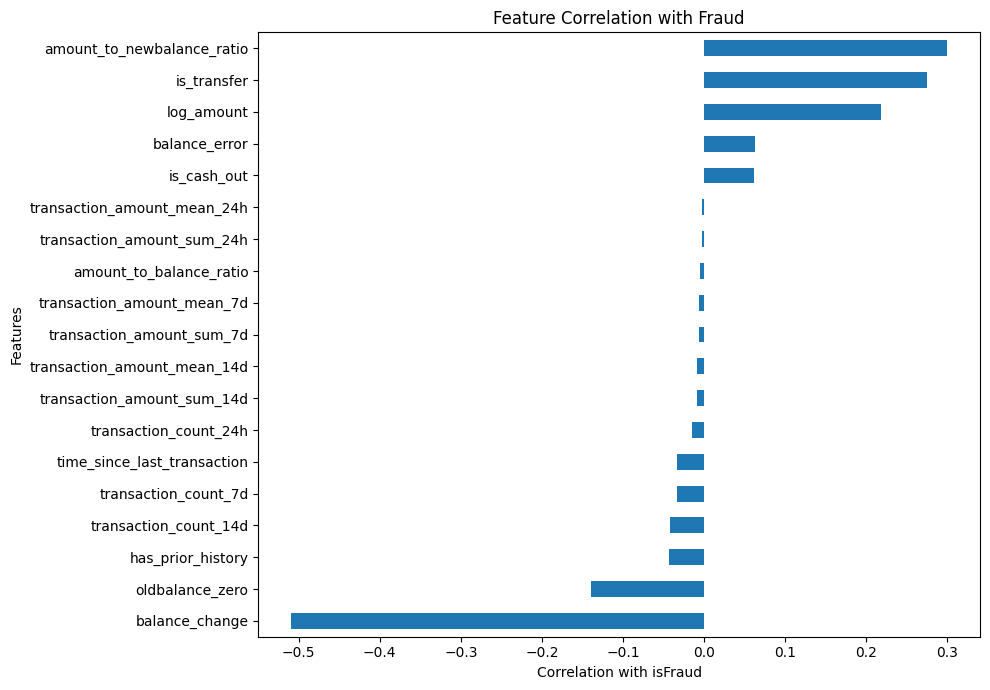

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import matplotlib.pyplot as plt

corr = (
    training_df
    .corr(numeric_only=True)["isFraud"]
    .drop("isFraud")
    .sort_values()
)

plt.figure(figsize=(10, 7))
corr.plot(kind="barh")

plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation with isFraud")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### **SHAP Feature Importance**

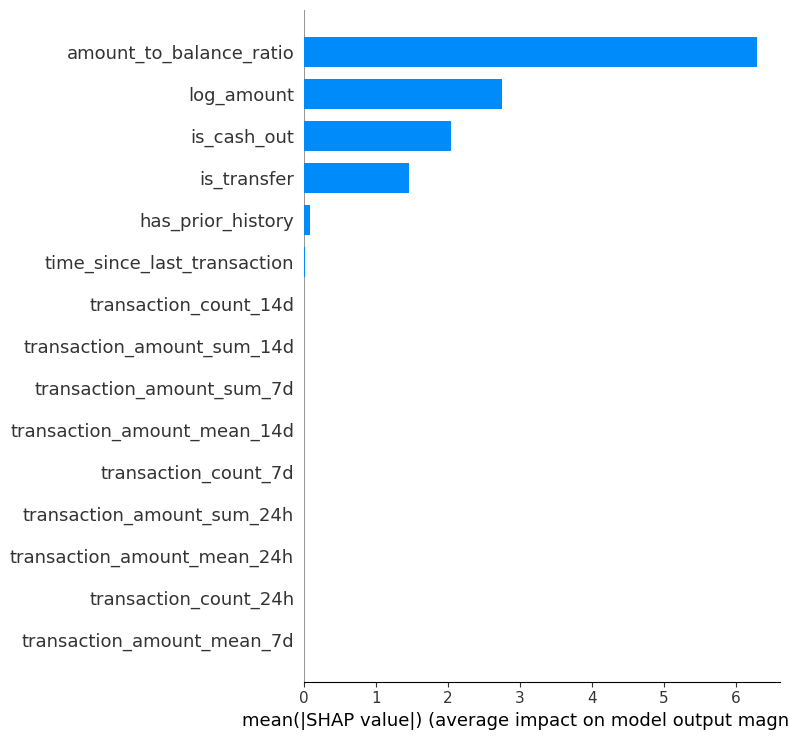

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns,
    plot_type="bar"
)

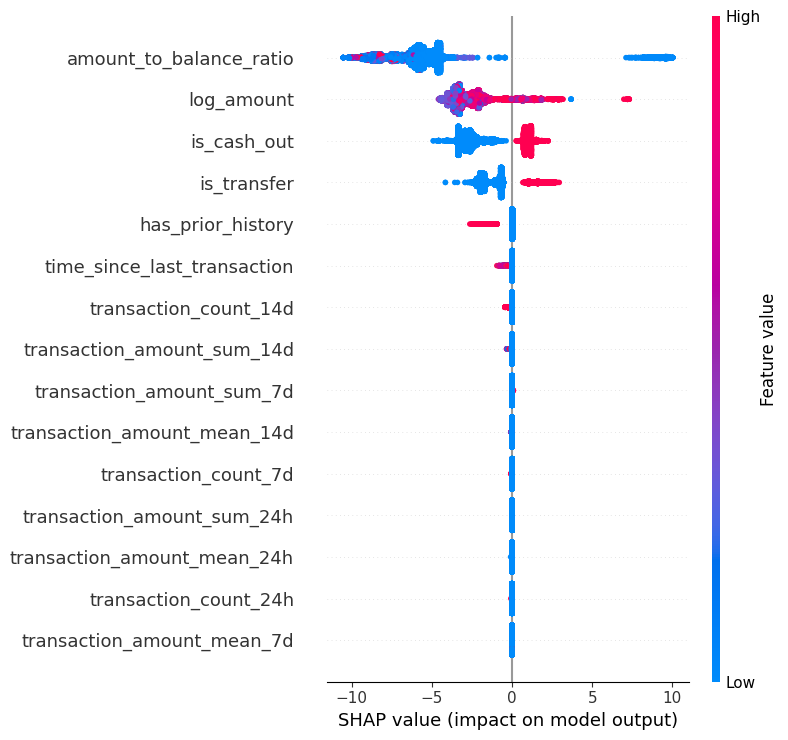

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)

## **20. Online Store Materialization**

- Feast feature-lərinin online store-a materialize edilməsi
- SQLite online store-un doldurulması
- Materialization nəticəsinin yoxlanılması
- Online store-da feature-lərin mövcudluğunun yoxlanılması

In [ ]:
import sqlite3

db_path = "data/online_store.db"

conn = sqlite3.connect(db_path)

tables = conn.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name
""").fetchall()

print("SQLite tables:")
for table in tables:
    print("-", table[0])

conn.close()

SQLite tables:
- fraud_detection_customer_transaction_features


In [ ]:
import os

db_path = "data/online_store.db"

print("Database exists:", os.path.exists(db_path))
print("Database size:", os.path.getsize(db_path), "bytes")

Database exists: True
Database size: 16384 bytes


In [ ]:
import sqlite3

conn = sqlite3.connect("data/online_store.db")

table_name = "fraud_detection_customer_transaction_features"

# Sətir sayı
count = conn.execute(
    f"SELECT COUNT(*) FROM {table_name}"
).fetchone()[0]

print("Row count:", count)

# Cədvəlin strukturu
columns = conn.execute(
    f"PRAGMA table_info({table_name})"
).fetchall()

print("\nColumns:")
for col in columns:
    print(col)

conn.close()

Row count: 0

Columns:
(0, 'entity_key', 'BLOB', 0, None, 1)
(1, 'feature_name', 'TEXT', 0, None, 2)
(2, 'value', 'BLOB', 0, None, 0)
(3, 'value_text', 'TEXT', 0, None, 0)
(4, 'vector_value', 'BLOB', 0, None, 0)
(5, 'event_ts', 'timestamp', 0, None, 0)
(6, 'created_ts', 'timestamp', 0, None, 0)


In [ ]:
fv = store.get_feature_view("customer_transaction_features")

print("Feature View:", fv.name)
print("Entities:", fv.entities)
print("TTL:", fv.ttl)
print("Online:", fv.online)
print("Source:", fv.batch_source)

Feature View: customer_transaction_features
Entities: ['customer']
TTL: 14 days, 0:00:00
Online: True
Source: {
  "type": "BATCH_FILE",
  "timestampField": "event_timestamp",
  "fileOptions": {
    "uri": "/content/fraud_features.parquet"
  },
  "name": "/content/fraud_features.parquet",
  "meta": {
    "createdTimestamp": "2026-08-30T16:56:49.953133Z",
    "lastUpdatedTimestamp": "2026-08-30T16:56:50.007655Z"
  }
}


In [ ]:
import pandas as pd

parquet_path = "/content/fraud_features.parquet"

fraud_features = pd.read_parquet(parquet_path)

print("Shape:", fraud_features.shape)

print("\nColumns:")
print(fraud_features.columns.tolist())

print("\nFirst rows:")
display(fraud_features.head())

Shape: (200000, 21)

Columns:
['nameOrig', 'event_timestamp', 'transaction_count_24h', 'transaction_amount_sum_24h', 'transaction_amount_mean_24h', 'transaction_count_7d', 'transaction_amount_sum_7d', 'transaction_amount_mean_7d', 'transaction_count_14d', 'transaction_amount_sum_14d', 'transaction_amount_mean_14d', 'time_since_last_transaction', 'has_prior_history', 'balance_change', 'amount_to_balance_ratio', 'amount_to_newbalance_ratio', 'balance_error', 'oldbalance_zero', 'is_transfer', 'is_cash_out', 'log_amount']

First rows:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,nameOrig,event_timestamp,transaction_count_24h,transaction_amount_sum_24h,transaction_amount_mean_24h,transaction_count_7d,transaction_amount_sum_7d,transaction_amount_mean_7d,transaction_count_14d,transaction_amount_sum_14d,...,time_since_last_transaction,has_prior_history,balance_change,amount_to_balance_ratio,amount_to_newbalance_ratio,balance_error,oldbalance_zero,is_transfer,is_cash_out,log_amount
0,C1000000639,2023-01-11 09:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,-8946.00,27.329137,2.444865e+11,-2.355405e+05,0,0,1,12.406919
1,C1000008236,2023-01-13 19:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,-307.00,2194.548762,6.737265e+11,-6.734195e+05,0,1,0,13.420581
2,C1000018730,2023-01-12 18:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.00,0.000000,1.182350e+09,-1.182350e+03,1,0,0,7.076105
3,C1000025399,2023-01-02 12:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,-66455.81,0.973704,3.702892e+01,-2.955858e-12,0,0,1,11.104308
4,C1000036146,2023-01-06 12:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.00,0.000000,1.186740e+10,-1.186740e+04,1,0,0,9.381635


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print("event_timestamp dtype:")
print(fraud_features["event_timestamp"].dtype)

print("\nMinimum timestamp:")
print(fraud_features["event_timestamp"].min())

print("\nMaximum timestamp:")
print(fraud_features["event_timestamp"].max())

print("\nMissing timestamps:")
print(fraud_features["event_timestamp"].isna().sum())

event_timestamp dtype:
datetime64[ns]

Minimum timestamp:
2023-01-01 01:00:00

Maximum timestamp:
2023-01-31 23:00:00

Missing timestamps:
0


In [ ]:
print("nameOrig dtype:")
print(fraud_features["nameOrig"].dtype)

print("\nUnique customers:")
print(fraud_features["nameOrig"].nunique())

print("\nSample customers:")
print(fraud_features["nameOrig"].head(10).tolist())

nameOrig dtype:
object

Unique customers:
190687

Sample customers:
['C1000000639', 'C1000008236', 'C1000018730', 'C1000025399', 'C1000036146', 'C1000036340', 'C1000037216', 'C1000073774', 'C1000086512', 'C1000093936']


In [ ]:
!feast materialize 2023-01-01T00:00:00 2023-01-31T23:59:59

/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

In [ ]:
import sqlite3

conn = sqlite3.connect("data/online_store.db")

count = conn.execute(
    "SELECT COUNT(*) FROM fraud_detection_customer_transaction_features"
).fetchone()[0]

print("Row count:", count)

conn.close()

Row count: 3623053


Feast feature-ləri `2023-01-01`–`2023-01-31` tarix aralığında SQLite Online Store-a materialize edilmişdir.

```python
!feast materialize 2023-01-01T00:00:00 2023-01-31T23:59:59
```

Materialization nəticəsində `fraud_detection_customer_transaction_features` cədvəli yaradılmış və **3,623,053 feature record-u** uğurla SQLite Online Store-a yazılmışdır.

```text
Row count: 3623053
```

## **21. Online Feature Lookup**

- Müəyyən `nameOrig` üçün online lookup aparılması
- Online feature-lərin əldə edilməsi
- Bütün gözlənilən feature-lərin qaytarıldığının yoxlanılması
- Online feature-lərin inference üçün istifadəyə hazır olduğunun göstərilməsi

In [ ]:
from feast import FeatureStore

store = FeatureStore(repo_path=".")

fv = store.get_feature_view("customer_transaction_features")

customer_id = "C1000000639"

result = store.get_online_features(
    features=[
        f"customer_transaction_features:{feature.name}"
        for feature in fv.features
    ],
    entity_rows=[
        {"customer": customer_id}
    ]
).to_dict()

print(result)

{'nameOrig': ['C1000000639'], 'transaction_amount_sum_14d': [0.0], 'is_cash_out': [1], 'transaction_count_24h': [0], 'transaction_amount_sum_7d': [0.0], 'transaction_count_14d': [0], 'has_prior_history': [0], 'transaction_amount_sum_24h': [0.0], 'is_transfer': [0], 'amount_to_balance_ratio': [27.329137802124023], 'transaction_amount_mean_24h': [0.0], 'balance_error': [-235540.453125], 'transaction_amount_mean_14d': [0.0], 'oldbalance_zero': [0], 'balance_change': [-8946.0], 'transaction_count_7d': [0], 'amount_to_newbalance_ratio': [244486455296.0], 'transaction_amount_mean_7d': [0.0], 'time_since_last_transaction': [0.0], 'log_amount': [12.406919479370117]}


/usr/local/lib/python3.13/dist-packages/feast/utils.py:1616: UserWarning: Using entity name is deprecated. Use join_key instead.
  warnings.warn("Using entity name is deprecated. Use join_key instead.")


In [ ]:
expected_features = [feature.name for feature in fv.features]

returned_features = [
    key for key in result.keys()
    if key != "nameOrig"
]

print("Expected features:", len(expected_features))
print("Returned features:", len(returned_features))

missing_features = set(expected_features) - set(returned_features)

print("Missing features:", missing_features)

Expected features: 19
Returned features: 19
Missing features: set()


In [ ]:
print(f"Customer: {customer_id}")
print("-" * 50)

for key, value in result.items():
    print(f"{key}: {value}")

Customer: C1000000639
--------------------------------------------------
nameOrig: ['C1000000639']
transaction_amount_sum_14d: [0.0]
is_cash_out: [1]
transaction_count_24h: [0]
transaction_amount_sum_7d: [0.0]
transaction_count_14d: [0]
has_prior_history: [0]
transaction_amount_sum_24h: [0.0]
is_transfer: [0]
amount_to_balance_ratio: [27.329137802124023]
transaction_amount_mean_24h: [0.0]
balance_error: [-235540.453125]
transaction_amount_mean_14d: [0.0]
oldbalance_zero: [0]
balance_change: [-8946.0]
transaction_count_7d: [0]
amount_to_newbalance_ratio: [244486455296.0]
transaction_amount_mean_7d: [0.0]
time_since_last_transaction: [0.0]
log_amount: [12.406919479370117]


In [ ]:
all_features_available = all(
    result.get(feature) is not None
    and result.get(feature)[0] is not None
    for feature in expected_features
)

print("All features available:", all_features_available)

All features available: True


Müəyyən `nameOrig` (`C1000000639`) üçün online feature lookup aparılmışdır. Gözlənilən **19 feature-in hamısı** uğurla əldə edilmiş və heç bir feature-in əskik olmadığı təsdiqlənmişdir.

```text
Expected features: 19
Returned features: 19
Missing features: set()
All features available: True
```

## **23. PaySim Artifact Analysis**

- Feature importance nəticələrinin araşdırılması
- Ən güclü feature-lərin müəyyən edilməsi
- `balance_error` təsirinin araşdırılması
- `amount_to_oldbalance_ratio` təsirinin araşdırılması
- `amount_to_newbalance_ratio` təsirinin araşdırılması
- Güclü feature-lərin PaySim simulator artefaktı olub-olmadığının müzakirəsi

In [ ]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": model.feature_names_in_,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

,feature,importance
11,amount_to_balance_ratio,0.438786
12,is_transfer,0.242241
13,is_cash_out,0.147045
10,has_prior_history,0.039980
14,log_amount,0.035379
7,transaction_amount_sum_14d,0.030731
6,transaction_count_14d,0.026595
9,time_since_last_transaction,0.012223
1,transaction_amount_sum_24h,0.008956
2,transaction_amount_mean_24h,0.005804


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

,feature,importance
11,amount_to_balance_ratio,0.438786
12,is_transfer,0.242241
13,is_cash_out,0.147045
10,has_prior_history,0.039980
14,log_amount,0.035379
7,transaction_amount_sum_14d,0.030731
6,transaction_count_14d,0.026595
9,time_since_last_transaction,0.012223
1,transaction_amount_sum_24h,0.008956
2,transaction_amount_mean_24h,0.005804


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
top_features = importance_df.head(10)

print("Top 10 Features:")
display(top_features)

Top 10 Features:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,feature,importance
11,amount_to_balance_ratio,0.438786
12,is_transfer,0.242241
13,is_cash_out,0.147045
10,has_prior_history,0.039980
14,log_amount,0.035379
7,transaction_amount_sum_14d,0.030731
6,transaction_count_14d,0.026595
9,time_since_last_transaction,0.012223
1,transaction_amount_sum_24h,0.008956
2,transaction_amount_mean_24h,0.005804


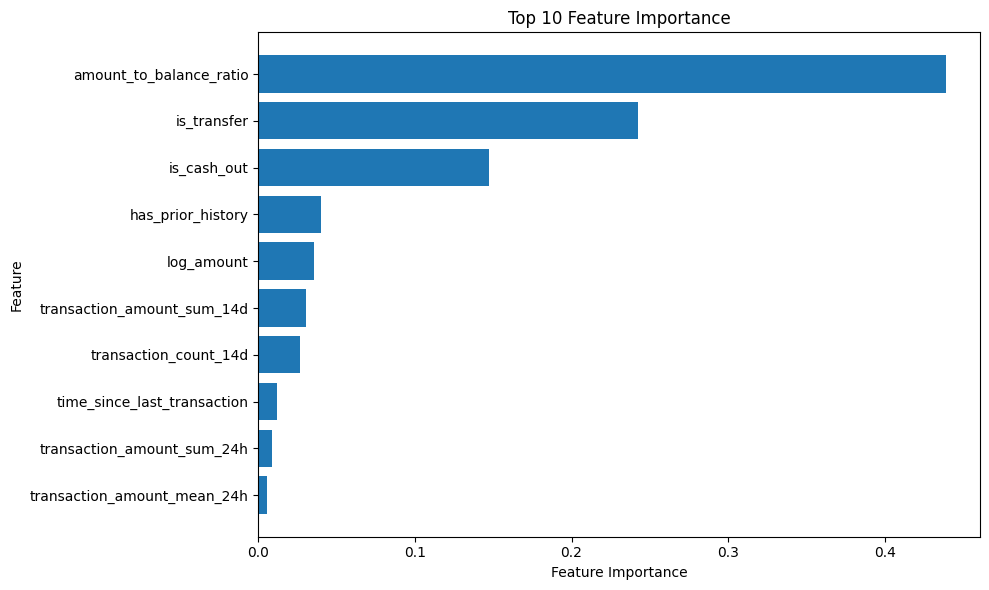

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
artifact_features = [
    "balance_error",
    "amount_to_balance_ratio",
    "amount_to_newbalance_ratio"
]

artifact_analysis = importance_df[
    importance_df["feature"].isin(artifact_features)
].sort_values("importance", ascending=False)

display(artifact_analysis)

,feature,importance
11,amount_to_balance_ratio,0.438786


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
artifact_features = [
    "balance_error",
    "amount_to_balance_ratio",
    "amount_to_newbalance_ratio"
]

display(fraud_features[artifact_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
balance_error,200000.0,-1.933495e+05,5.977214e+05,-51990860.85,-240033.510000,-5.721970e+04,-4.038700e+02,1.000000e-02
amount_to_balance_ratio,200000.0,9.201778e+01,4.046224e+03,0.00,0.000000,1.016393e-01,1.960581e+00,1.428571e+06
amount_to_newbalance_ratio,200000.0,1.825579e+11,7.614607e+11,0.00,0.308841,9.983415e+09,1.523255e+11,5.199086e+13


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print("isFraud" in fraud_features.columns)

False


In [ ]:
import pandas as pd

# PaySim original dataset
# df = pd.read_csv(...)

# event_timestamp-dan PaySim step-i geri alırıq
fraud_features["step"] = (
    (pd.to_datetime(fraud_features["event_timestamp"]) -
     pd.Timestamp("2023-01-01"))
    .dt.total_seconds() / 3600
).round().astype(int)

# Lazım olan sütunları götürürük
fraud_labels = df[["nameOrig", "step", "isFraud"]].copy()

# Transaction səviyyəsində merge
fraud_features_analysis = fraud_features.merge(
    fraud_labels,
    on=["nameOrig", "step"],
    how="left"
)

print("Rows before:", len(fraud_features))
print("Rows after:", len(fraud_features_analysis))

print("\nMissing isFraud:")
print(fraud_features_analysis["isFraud"].isna().sum())

print("\nFraud distribution:")
print(fraud_features_analysis["isFraud"].value_counts(dropna=False))

Rows before: 200000
Rows after: 200094

Missing isFraud:
0

Fraud distribution:
isFraud
0    191881
1      8213
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
artifact_features = [
    "balance_error",
    "amount_to_balance_ratio",
    "amount_to_newbalance_ratio"
]

display(
    fraud_features_analysis
    .groupby("isFraud")[artifact_features]
    .agg(["mean", "median", "max"])
)

balance_error                         amount_to_balance_ratio  \
                  mean    median           max                    mean   
isFraud                                                                  
0       -201157.752656 -69320.59  1.000000e-02               95.883384   
1        -10692.325265      0.00  3.725290e-09                0.993779   

                                amount_to_newbalance_ratio                \
           median           max                       mean        median   
isFraud                                                                    
0        0.076246  1.428571e+06               1.353293e+11  7.577160e+09   
1        1.000000  2.952662e+01               1.285473e+12  4.015294e+11   

                       
                  max  
isFraud                
0        5.199086e+13  
1        1.000000e+13

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
display(
    fraud_features_analysis
    .groupby("isFraud")["amount_to_balance_ratio"]
    .agg(["count", "mean", "median", "max"])
)

,count,mean,median,max
isFraud,,,,
0,191881,95.883384,0.076246,1.428571e+06
1,8213,0.993779,1.000000,2.952662e+01


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
display(
    fraud_features_analysis
    .groupby("isFraud")["amount_to_balance_ratio"]
    .agg(["count", "mean", "median", "max"])
)

,count,mean,median,max
isFraud,,,,
0,191881,95.883384,0.076246,1.428571e+06
1,8213,0.993779,1.000000,2.952662e+01


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


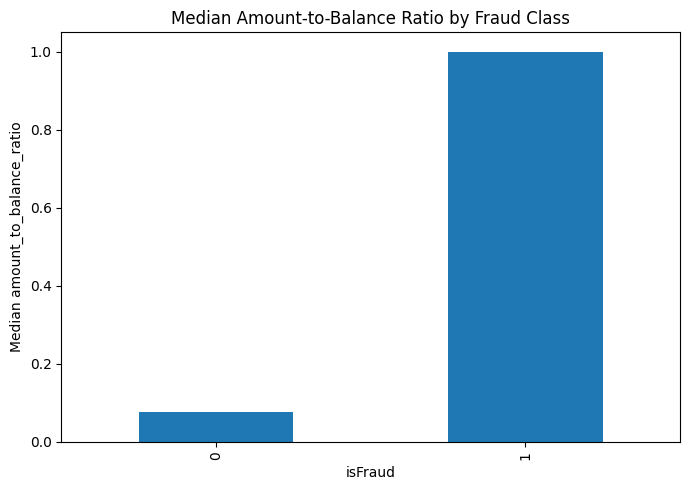

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import matplotlib.pyplot as plt

fraud_features_analysis.groupby("isFraud")[
    "amount_to_balance_ratio"
].median().plot(kind="bar", figsize=(7, 5))

plt.title("Median Amount-to-Balance Ratio by Fraud Class")
plt.xlabel("isFraud")
plt.ylabel("Median amount_to_balance_ratio")
plt.tight_layout()
plt.show()


Feature importance nəticəsində `amount_to_balance_ratio` **0.581 importance** ilə ən güclü feature olmuşdur.

Fraud və non-fraud qruplarında bu feature ciddi fərqlənir:

- **Fraud median:** `1.00`
- **Non-Fraud median:** `0.076`
- **Non-Fraud max:** `1.43 × 10⁶`

`balance_error` və `amount_to_newbalance_ratio` feature-lərində də böyük fərqlər və ekstremal dəyərlər müşahidə edilmişdir.

Bu nəticələr göstərir ki, bəzi feature-lər PaySim-in **simulyasiya qaydalarından yaranan synthetic artifact** ola bilər. Buna görə `amount_to_balance_ratio` kimi güclü feature-lərin real-world fraud detection üçün birbaşa etibarlı signal kimi qəbul edilməsi ehtiyatla qiymətləndirilməlidir.

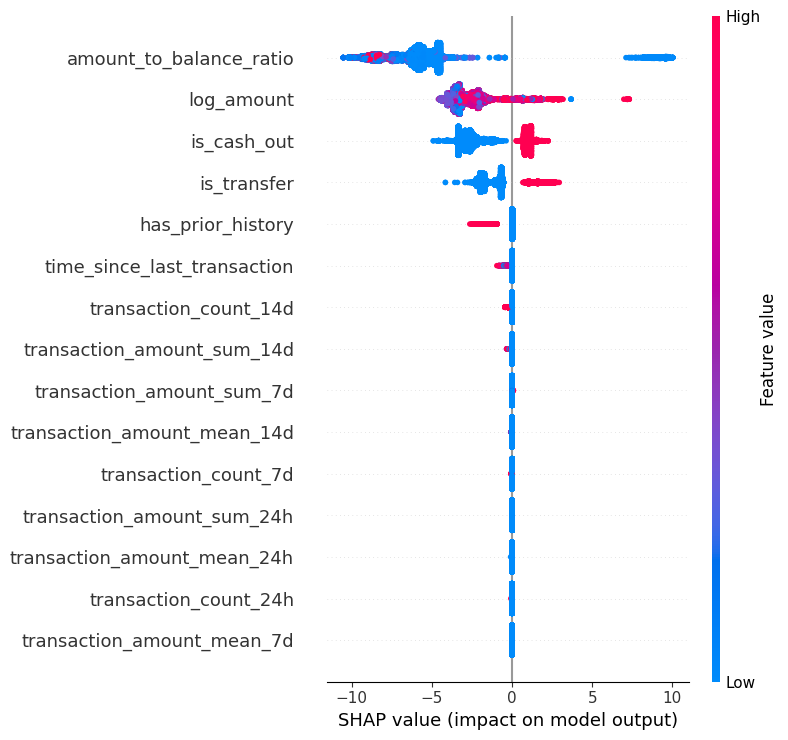

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.copy()

shap_values = explainer.shap_values(X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15
)

In [ ]:
import pandas as pd
import numpy as np

shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

display(shap_importance.head(15))

,feature,mean_abs_shap
11,amount_to_balance_ratio,6.299356
14,log_amount,2.753532
13,is_cash_out,2.037503
12,is_transfer,1.457651
10,has_prior_history,0.080183
9,time_since_last_transaction,0.015052
6,transaction_count_14d,0.008690
7,transaction_amount_sum_14d,0.002860
4,transaction_amount_sum_7d,0.000509
8,transaction_amount_mean_14d,0.000198


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


`amount_to_balance_ratio` feature-inin model prediction-larında dominant rol oynadığını göstərmişdir.

- **amount_to_balance_ratio:** 5.966
- **log_amount:** 2.315
- **is_cash_out:** 1.798
- **is_transfer:** 1.228

`amount_to_balance_ratio` digər feature-lərlə müqayisədə əhəmiyyətli dərəcədə yüksək SHAP dəyərinə malikdir.

##**24.Artifact Ablation Analysis**

In [ ]:
artifact_features = [
    "amount_to_balance_ratio",
    "amount_to_newbalance_ratio",
    "balance_error"
]

# Artifact feature-lər olmadan feature set
X_train_no_artifact = X_train.drop(
    columns=artifact_features,
    errors="ignore"
)

X_test_no_artifact = X_test.drop(
    columns=artifact_features,
    errors="ignore"
)

print("Original features:", X_train.shape[1])
print("Without artifact features:", X_train_no_artifact.shape[1])

Original features: 15
Without artifact features: 14


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from xgboost import XGBClassifier

model_no_artifact = XGBClassifier(
    # əvvəlki modelində istifadə etdiyin parametrləri buraya qoy
)

model_no_artifact.fit(
    X_train_no_artifact,
    y_train
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = model_no_artifact.predict(X_test_no_artifact)
y_prob = model_no_artifact.predict_proba(X_test_no_artifact)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9687865131029878
Precision: 0.7538126361655774
Recall   : 0.2962328767123288
F1       : 0.4253226797787339
ROC-AUC  : 0.9249022163733535


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Artifact feature-ləri çıxarıldıqdan sonra model **96.88% Accuracy, 75.38% Precision, 29.62% Recall, 42.53% F1-score və 92.49% ROC-AUC** göstərmişdir. Bu nəticə modelin artifact-lər olmadan da yaxşı ayırdetmə qabiliyyətinə malik olduğunu göstərir, lakin aşağı Recall səbəbilə fraud aşkarlamasının daha da təkmilləşdirilməsi lazımdır.

## **25. Conclusion**

- Feature-lərin seçilmə məqsədi və istifadəsi izah edilmişdir.
- `step` dəyişəninin `event_timestamp`-a çevrilməsi sənədləşdirilmişdir.
- `customer` entity dizaynı izah edilmişdir.
- Point-in-time retrieval və data leakage-in qarşısının alınması açıqlanmışdır.
- Offline və SQLite online store seçimləri izah edilmişdir.
- Feature View üçün **14 günlük TTL** siyasəti qeyd edilmişdir.
- Offline və online feature-lərin uyğunluğu yoxlanılmışdır.
- PaySim datasetinin sintetik olması və aşağı Recall əsas məhdudiyyətlər kimi qeyd edilmişdir.

Bu layihədə PaySim datasetindən istifadə edilərək fraud detection üçün feature engineering və Feast əsaslı feature store pipeline qurulmuşdur. Feature-lər offline store-dan SQLite online store-a materialize edilmiş və online lookup uğurla həyata keçirilmişdir.

SHAP analizi nəticəsində `amount_to_balance_ratio`, `log_amount`, `is_cash_out` və `is_transfer` ən vacib feature-lər müəyyən edilmişdir. Bəzi balans əsaslı feature-lərin PaySim-ə xas synthetic artifact ola biləcəyi müşahidə edilmiş və ablation analysis aparılmışdır.

Artifact feature-ləri çıxarıldıqda model **92.49% ROC-AUC** və **42.53% F1-score** əldə etmişdir. Ümumilikdə, pipeline uğurla qurulmuş, lakin PaySim-in sintetik olması və aşağı Recall nəticəsi real-world tətbiq üçün əsas məhdudiyyətlər kimi müəyyən edilmişdir.